# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python04 - Data Standardization</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **What is Data Standardization?**

**Data standardization** is a crucial preprocessing step in data mining and machine learning. It involves transforming your data so that each feature has the same scale, typically with a mean of 0 and a standard deviation of 1. This ensures that all variables contribute equally to the analysis and model training.

---

## **Why Standardize Data?**

### 1. **Improves Model Performance**
Some machine learning algorithms, such as **k-nearest neighbors**, **support vector machines**, and **gradient descent-based models**, are sensitive to the scale of input data. Standardization ensures that features with large magnitudes do not dominate features with smaller magnitudes.

### 2. **Enhances Interpretability**
Standardized data allows for better interpretability of results, especially in models where coefficients indicate the importance of features.

### 3. **Speeds Up Convergence**
In optimization-based models (e.g., logistic regression, neural networks), standardizing the data can lead to faster convergence during training.

---


## Analyzing data

In [4]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()


In [5]:
print(dataset["DESCR"])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [6]:
#create the dataframe
dataset_df = pd.DataFrame(dataset.data)

columns = dataset.feature_names
dataset_df.columns = columns

dataset_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
dataset_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Creating and Customizing a Boxplot**

#### **Objective**
Learn how to create and customize a **boxplot** using Matplotlib to visualize the distribution of data across multiple features.

---

#### **Instructions**
1. Import the necessary libraries:  
   - `pandas` for creating a dataset.
   - `matplotlib.pyplot` for plotting.

2. Create a Pandas DataFrame `dataset_df` with at least **four columns** and **random numeric data**.  
   *(Hint: Use `np.random.rand()` to generate random data.)*

3. Generate a **basic boxplot** and **basic histograms** of the DataFrame using `dataset_df.boxplot()`.


4. Display the final customized boxplot.

</div>

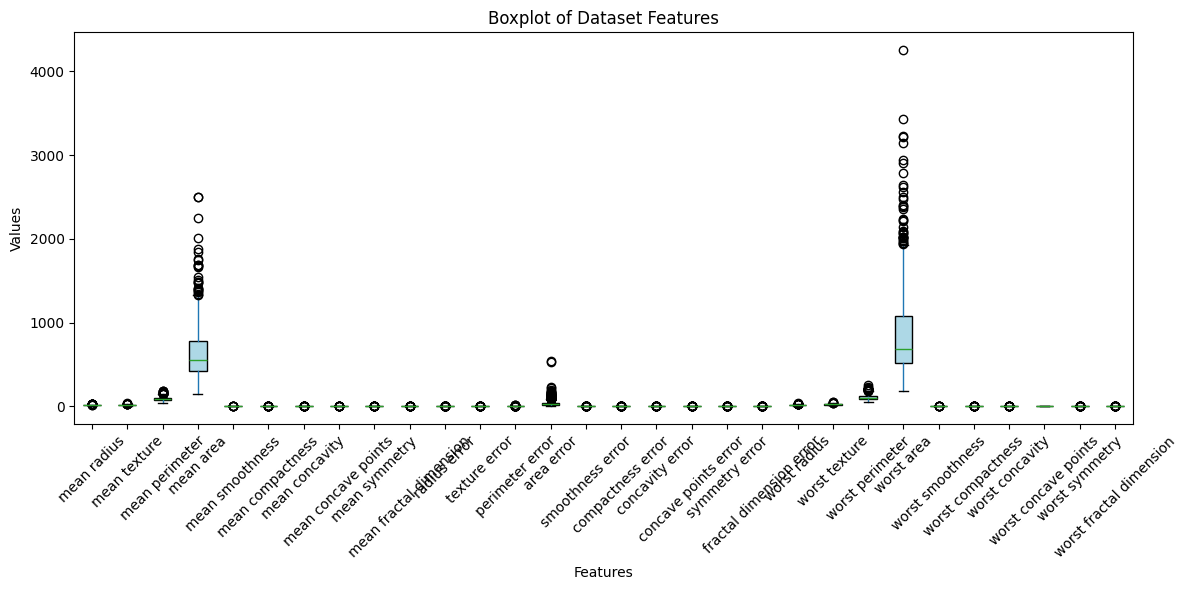

In [8]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))  # Set the figure size
dataset_df.boxplot(rot=45, grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Boxplot of Dataset Features")  # Add a title
plt.ylabel("Values")  # Add a y-axis label
plt.xlabel("Features")  # Add an x-axis label
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()




<img src="boxplot_features.png" />

<Figure size 1500x1500 with 0 Axes>

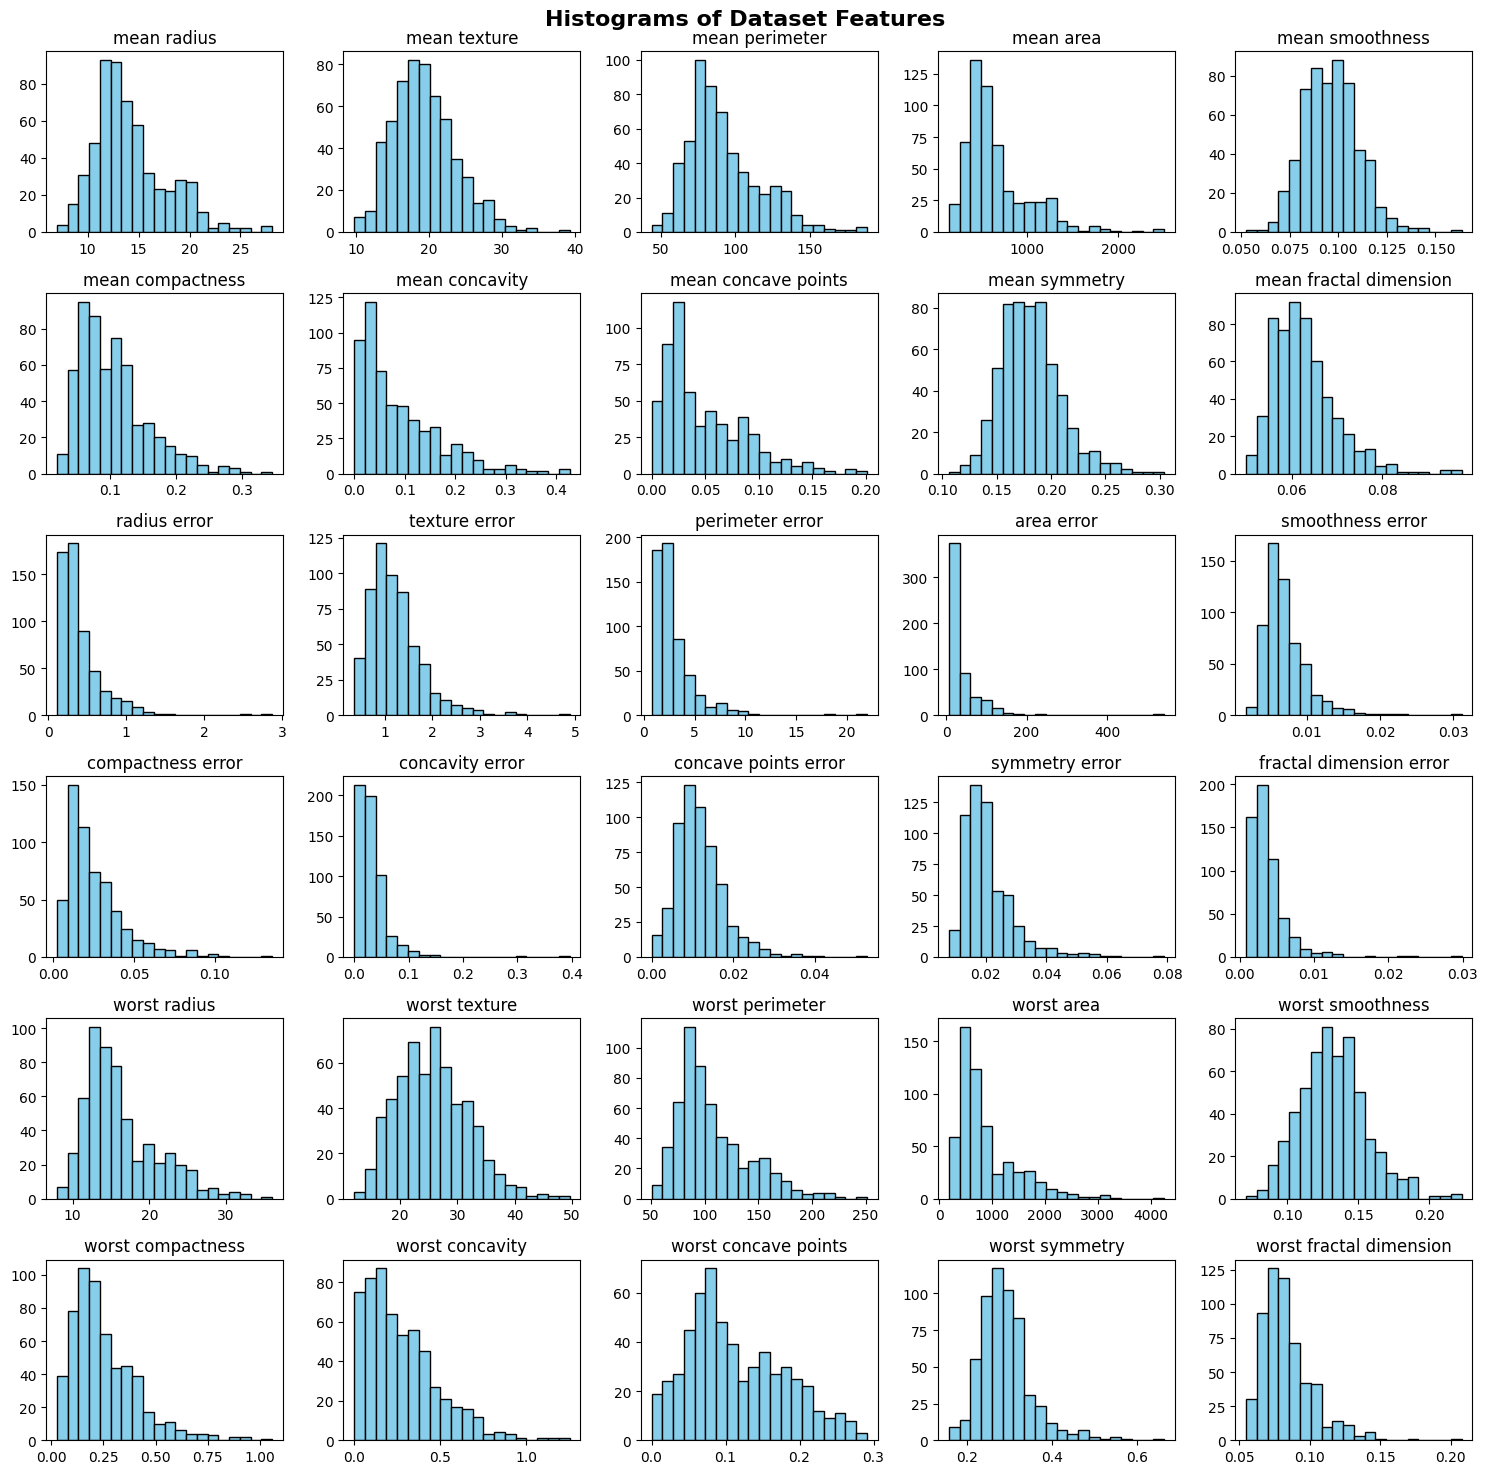

In [9]:
# Improved histogram visualization
plt.figure(figsize=(15, 15))  # Set the figure size
dataset_df.hist(bins=20, figsize=(15, 15), color='skyblue', edgecolor='black', grid=False)

# Add a main title for all histograms
plt.suptitle("Histograms of Dataset Features", fontsize=16, fontweight='bold')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

<img src="histogram.png" />

# **Standardization with StandardScaler**

---

### **What is Standardization?**
Standardization is a preprocessing technique that transforms features to have a **mean of 0** and a **standard deviation of 1**. This ensures that all features contribute equally to the analysis, avoiding dominance by features with larger magnitudes.

Mathematically, for each feature $X_j$, the standardized value \( Z_j \) is calculated as:

$
Z_j = \frac{X_j - \mu_j}{\sigma_j}
$

Where:
- $ Z_j $: The standardized value of the feature \( X_j \).
- $ X_j $: The original feature value.
- $ \mu_j $: The **mean** of the feature \( X_j \) (calculated on the training data).
- $ \sigma_j $: The **standard deviation** of the feature \( X_j \) (calculated on the training data).

---

### **Why Standardize Data?**
1. **Improves Model Performance**:
   - Models like **SVM**, **Logistic Regression**, and **KNN** are sensitive to the scale of features.
2. **Assumes Normalized Features**:
   - Techniques like **PCA** and **LDA** assume the data is normally distributed.
3. **Balances Feature Contribution**:
   - Prevents features with large magnitudes from dominating those with smaller ones.

---

### **StandardScaler in Practice**

The `StandardScaler` class from `sklearn.preprocessing` is used to perform standardization in Python. It works by:
1. **Fitting** on the training data to compute the mean (\( \mu_j \)) and standard deviation (\( \sigma_j \)) for each feature.
2. **Transforming** the dataset by centering (subtracting the mean) and scaling (dividing by the standard deviation).



<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise: Standardize and Visualize Data with `StandardScaler`**

#### **Objective**
Learn how to use **`StandardScaler`** from `sklearn.preprocessing` to standardize your dataset and visualize the standardized data using a boxplot.

---

#### **Instructions**
1. **Fit the Scaler**:
   - Use `StandardScaler` to compute the mean and standard deviation for the features in the dataset.
   
2. **Transform the Data**:
   - Apply the transformation to standardize the dataset.  

3. **Convert to DataFrame**:
   - Convert the standardized data back into a Pandas DataFrame with the same column names as the original dataset.

4. **Plot the Boxplot**:
   - Create a **boxplot** for the standardized data to compare the feature distributions after standardization.

---

#### **Hints**
- Use `scaler.fit()` to compute the required statistics (mean and standard deviation).
- Use `scaler.transform()` to standardize the dataset.
- Use `pd.DataFrame()` to create a new DataFrame from the transformed data.
- Use `plt.boxplot()` or Pandas' `boxplot()` method for visualization.


</div>

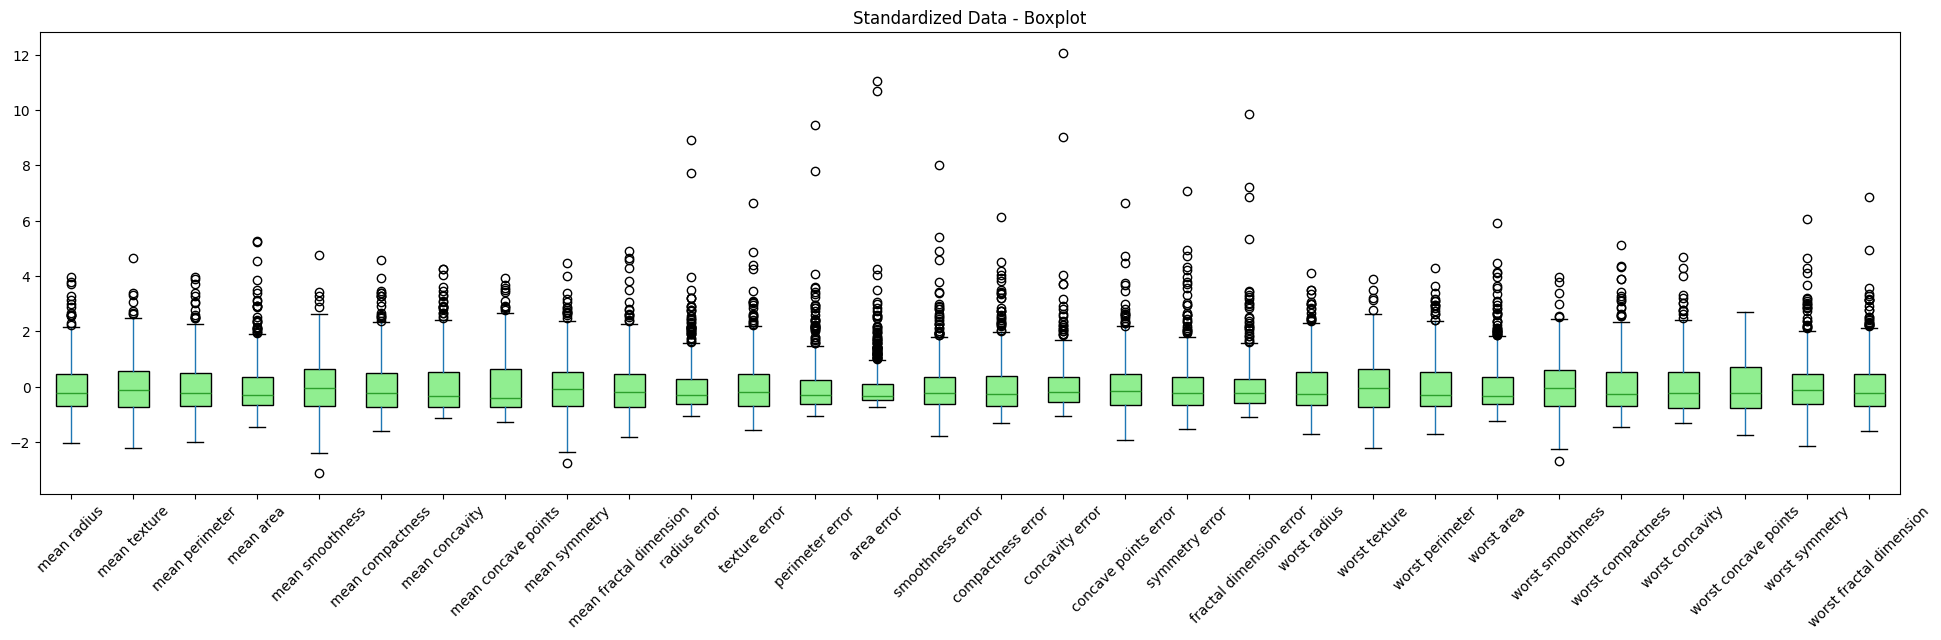

In [10]:
from sklearn.preprocessing import StandardScaler
# Step 3: Standardize the dataset
scaler = StandardScaler()
scaler.fit(dataset_df)  # Fit the scaler
standardized_data = scaler.transform(dataset_df)  # Transform the data

# Convert standardized data back into a DataFrame
standardized_df = pd.DataFrame(standardized_data, columns=dataset_df.columns)

# Step 4: Visualize standardized data
plt.figure(figsize=(24, 6))
standardized_df.boxplot(rot=45, grid=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title("Standardized Data - Boxplot")
plt.show()

<img src="standardizer.png"/>

## **Using MinMaxScaler**

---
The `MinMaxScaler` is a data preprocessing technique from `sklearn.preprocessing` used to **normalize features** by scaling them to a specific range, typically [0, 1]. Unlike `StandardScaler`, which standardizes data to have a mean of 0 and unit variance, `MinMaxScaler` rescales the data linearly between a minimum and maximum value.

---

### **Formula**
The transformation performed by `MinMaxScaler` is given by:

$
X' = \frac{X - \text{X}_{\text{min}}}{\text{X}_{\text{max}} - \text{X}_{\text{min}}}
$

Where:
- $ X $: Original feature value.
- $ X_{\text{min}} $: Minimum value of the feature in the dataset.
- $X_{\text{max}}$: Maximum value of the feature in the dataset.
- $ X' $: Scaled value between 0 and 1.

This transformation scales each feature independently.

---

### **Why Use MinMaxScaler?**

1. **Normalization for Specific Ranges**:
   - MinMaxScaler is particularly useful when you want all features to lie within a specific range (e.g., [0, 1] or [-1, 1]).

2. **Avoiding Feature Dominance**:
   - Rescales features to ensure no single feature dominates others during computation (e.g., in distance-based algorithms like KNN or clustering).

3. **Maintains Distribution Shape**:
   - Unlike `StandardScaler`, MinMaxScaler does not distort the shape of the original feature distribution.

4. **Best for Bounded Models**:
   - Particularly beneficial for machine learning algorithms sensitive to absolute scales, such as **neural networks** or when features need to fit into a specific activation function range.


<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Normalize Data Using MinMaxScaler**

#### **Objective**
Learn how to use Scikit-Learn's `MinMaxScaler` to normalize data to a specified range, such as **(-1, 1)**. This exercise will teach you how to scale feature values in a DataFrame.

---

#### **Instructions**

1. **Create or Load a Dataset**:
   - Create a Pandas DataFrame named `dataset_df` with at least **three columns** and **random numerical data**. *(Hint: Use `np.random.rand()` to generate random numbers.)*
   - Alternatively, use a real dataset if available.

2. **Initialize MinMaxScaler**:
   - Initialize the `MinMaxScaler` with the following parameters:
     - `copy=False`: Ensures the scaling is done **in place** without creating a copy.
     - `feature_range=(-1, 1)`: Scales all features into the range [-1, 1].

3. **Fit and Transform the Dataset**:
   - Apply `fit_transform()` to normalize the data.

4. **Verify Results**:
   - Print the **original data** and the **normalized data**.
   - Verify that all feature values now lie within the range [-1, 1].



In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Step 1: Create a sample dataset
np.random.seed(42)
data = {
    "Feature_1": np.random.rand(10) * 100,
    "Feature_2": np.random.rand(10) * 50 + 20,
    "Feature_3": np.random.rand(10) * 10 + 5
}
dataset_df = pd.DataFrame(data)
print("Original Dataset:")
print(dataset_df)

# Step 2: Initialize MinMaxScaler
mm_scaler = MinMaxScaler(copy=False, feature_range=(-1, 1))

# Step 3: Fit and Transform the data
mm_scaler.fit_transform(dataset_df)

# Step 4: Print the normalized dataset
print("\nNormalized Dataset (Range: -1 to 1):")
print(dataset_df)

Original Dataset:
   Feature_1  Feature_2  Feature_3
0  37.454012  21.029225  11.118529
1  95.071431  68.495493   6.394939
2  73.199394  61.622132   7.921446
3  59.865848  30.616956   8.663618
4  15.601864  29.091248   9.560700
5  15.599452  29.170225  12.851760
6   5.808361  35.212112   6.996738
7  86.617615  46.237822  10.142344
8  60.111501  41.597251  10.924146
9  70.807258  34.561457   5.464504

Normalized Dataset (Range: -1 to 1):
   Feature_1  Feature_2  Feature_3
0  -0.290958  -1.000000   0.530751
1   1.000000   1.000000  -0.748097
2   0.509942   0.710390  -0.334816
3   0.211195  -0.596019  -0.133883
4  -0.780570  -0.660305   0.108990
5  -0.780624  -0.656977   1.000000
6  -1.000000  -0.402401  -0.585168
7   0.810586   0.062169   0.266462
8   0.216699  -0.133362   0.478124
9   0.456345  -0.429817  -1.000000
